# Day 5.2: Techniques for Handling Imbalance

## Table of Contents
1. [Introduction](#introduction)
2. [Data-Level Approaches: Resampling](#data-level-approaches-resampling)
   - [Oversampling the Minority Class](#oversampling-the-minority-class)
   - [Undersampling the Majority Class](#undersampling-the-majority-class)
   - [Combining Approaches](#combining-approaches)
3. [Algorithm-Level Approaches: Cost-Sensitive Learning](#algorithm-level-approaches-cost-sensitive-learning)
   - [Class Weights](#class-weights)
   - [Finding Optimal Weights](#finding-optimal-weights)
4. [Threshold Adjustment](#threshold-adjustment)
5. [Comparison of Techniques](#comparison-of-techniques)
6. [Knowledge Check](#knowledge-check)
7. [Summary](#summary)

## Introduction

In the previous section, we explored the challenges presented by imbalanced datasets. Now, we'll focus on practical techniques to address these challenges. Broadly, these techniques fall into three categories:

1. **Data-level approaches**: Modify the dataset to balance class distribution
2. **Algorithm-level approaches**: Modify the learning algorithm to be more sensitive to the minority class
3. **Threshold adjustment**: Modify the classification threshold

Let's explore each of these approaches, with practical examples.

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

## Data-Level Approaches 

The core idea here is to change the composition of your training dataset to provide a more balanced view to the learning algorithm.

Why it's used: Many standard algorithms implicitly assume or perform better with a balanced class distribution. By rebalancing, you can prevent the model from becoming biased towards the majority class and help it learn the characteristics of the minority class more effectively.

There are two main approaches: **oversampling the minority class** and **undersampling the majority class**.

Let's first create an imbalanced dataset to work with:

In [6]:
# Create an imbalanced dataset (90% class 0, 10% class 1)
X, y = make_classification(
    n_samples=10000, 
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],
    random_state=42
)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check class distribution
train_class_counts = pd.Series(y_train).value_counts()
print("Training set class distribution:")
for cls, count in train_class_counts.items():
    print(f"Class {cls}: {count} samples ({count/len(y_train):.2%})")

Training set class distribution:
Class 0: 6276 samples (89.66%)
Class 1: 724 samples (10.34%)


Let's visualize our imbalanced dataset:

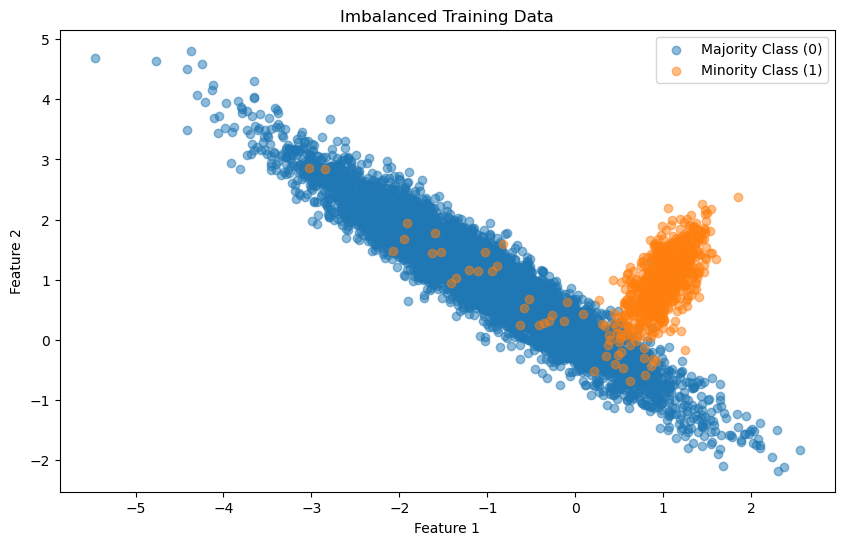

In [7]:
# Visualize the imbalanced dataset
plt.figure(figsize=(10, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 
            alpha=0.5, label='Majority Class (0)')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
            alpha=0.5, label='Minority Class (1)')
plt.title('Imbalanced Training Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

First, let's train a baseline model to see the effects of imbalance:

Baseline Model Performance:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2690
           1       1.00      0.89      0.94       310

    accuracy                           0.99      3000
   macro avg       0.99      0.95      0.97      3000
weighted avg       0.99      0.99      0.99      3000



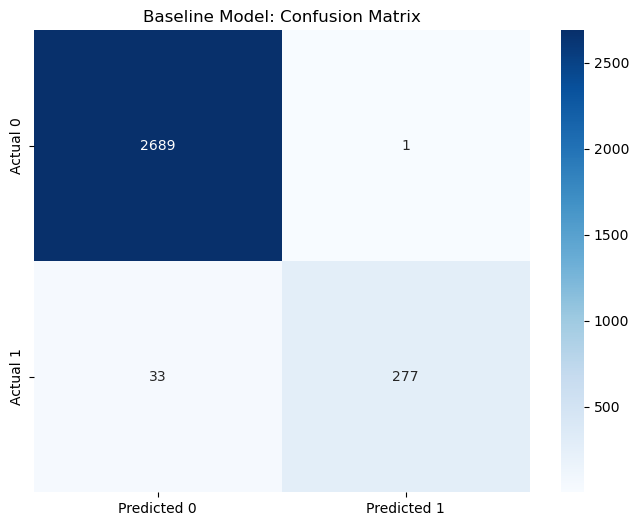

In [8]:
# Train a baseline logistic regression model
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Evaluate
print("Baseline Model Performance:")
print(classification_report(y_test, y_pred_baseline))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Baseline Model: Confusion Matrix')
plt.show()

### 1. Oversampling Techniques

Oversampling increases the number of minority class instances to balance the class distribution. This approach preserves all information in the original dataset while adding new examples.

#### 1.1 Random Oversampling

Random oversampling duplicates examples from the minority class randomly until a desired balance is achieved.

##### Theory
- Randomly select examples from the minority class with replacement
- Duplicate these examples to increase the minority class size
- Continue until target distribution is reached

##### Advantages
- Simple to implement and understand
- No information loss from the original dataset
- Computationally inexpensive
- Improves recall for minority class
- Works well when dataset is small

##### Disadvantages
- Risk of overfitting since exact duplicates are created
- Doesn't add new information to the dataset
- Can amplify the effect of noisy instances
- May lead to decision boundary overly specific to training examples

##### Implementation

In [26]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np

# Create and apply the oversampler
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

# Check new class distribution
unique, counts = np.unique(y_resampled, return_counts=True)
print(dict(zip(unique, counts)))

{0: 6276, 1: 6276}


In [27]:
# Apply random oversampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

# Check new class distribution
ros_class_counts = pd.Series(y_train_ros).value_counts()
print("Class distribution after random oversampling:")
for cls, count in ros_class_counts.items():
    print(f"Class {cls}: {count} samples ({count/len(y_train_ros):.2%})")

Class distribution after random oversampling:
Class 0: 6276 samples (50.00%)
Class 1: 6276 samples (50.00%)


Let's visualize the data after random oversampling:

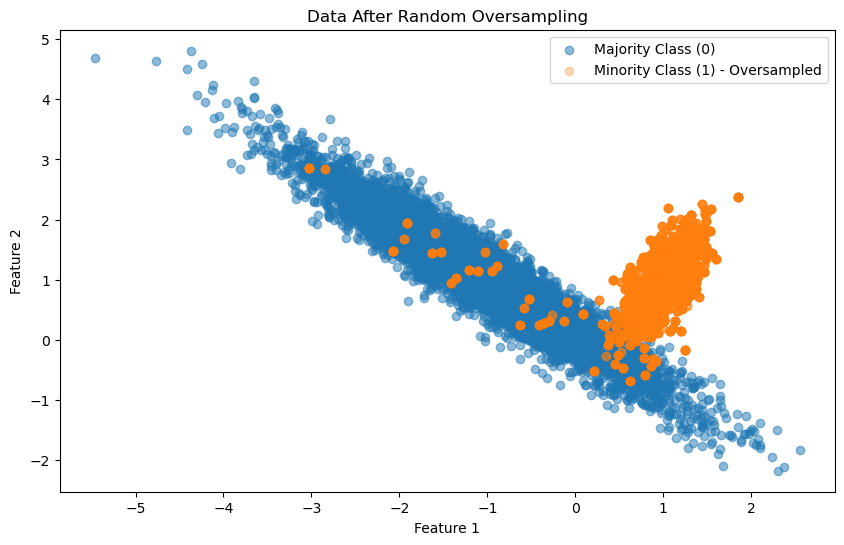

In [28]:
# Convert back to original feature space for visualization
X_train_ros_orig = scaler.inverse_transform(X_train_ros)

# Separate by class
X_train_ros_0 = X_train_ros_orig[y_train_ros == 0]
X_train_ros_1 = X_train_ros_orig[y_train_ros == 1]

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_train_ros_0[:, 0], X_train_ros_0[:, 1], 
            alpha=0.5, label='Majority Class (0)')
plt.scatter(X_train_ros_1[:, 0], X_train_ros_1[:, 1], 
            alpha=0.3, label='Minority Class (1) - Oversampled')
plt.title('Data After Random Oversampling')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

Now let's train a model on this oversampled data:

In [29]:
# Train model with random oversampling
ros_model = LogisticRegression(random_state=42)
ros_model.fit(X_train_ros, y_train_ros)
y_pred_ros = ros_model.predict(X_test_scaled)

# Evaluate
print("Model Performance with Random Oversampling:")
print(classification_report(y_test, y_pred_ros))

Model Performance with Random Oversampling:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2690
           1       0.88      0.95      0.91       310

    accuracy                           0.98      3000
   macro avg       0.93      0.97      0.95      3000
weighted avg       0.98      0.98      0.98      3000



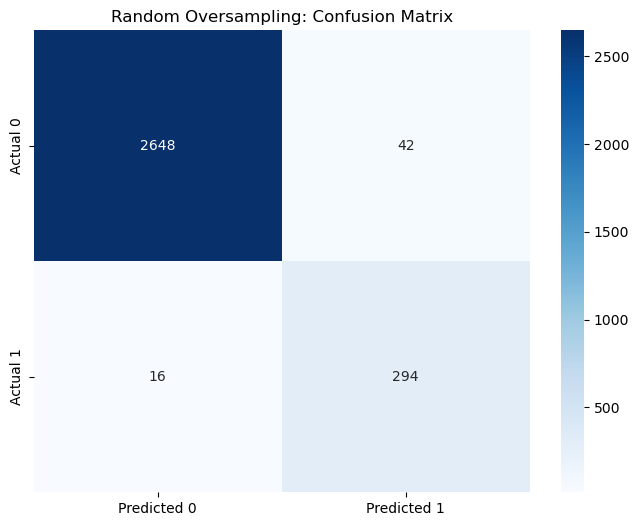

In [30]:
# Plot confusion matrix
cm_ros = confusion_matrix(y_test, y_pred_ros)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ros, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Random Oversampling: Confusion Matrix')
plt.show()

### 1.2 SMOTE (Synthetic Minority Over-sampling Technique)

This is a more sophisticated method. Instead of just duplicating, SMOTE creates new synthetic samples. 

SMOTE generates synthetic examples rather than creating exact copies, addressing some limitations of random oversampling.

#### Theory
- For each minority class example:
  1. Find k nearest neighbors in the minority class
  2. Select one of these neighbors randomly
  3. Create a synthetic example along the line connecting the example and its neighbor
  4. The synthetic example = original example + random value between 0 and 1 * difference between the example and its neighbor



  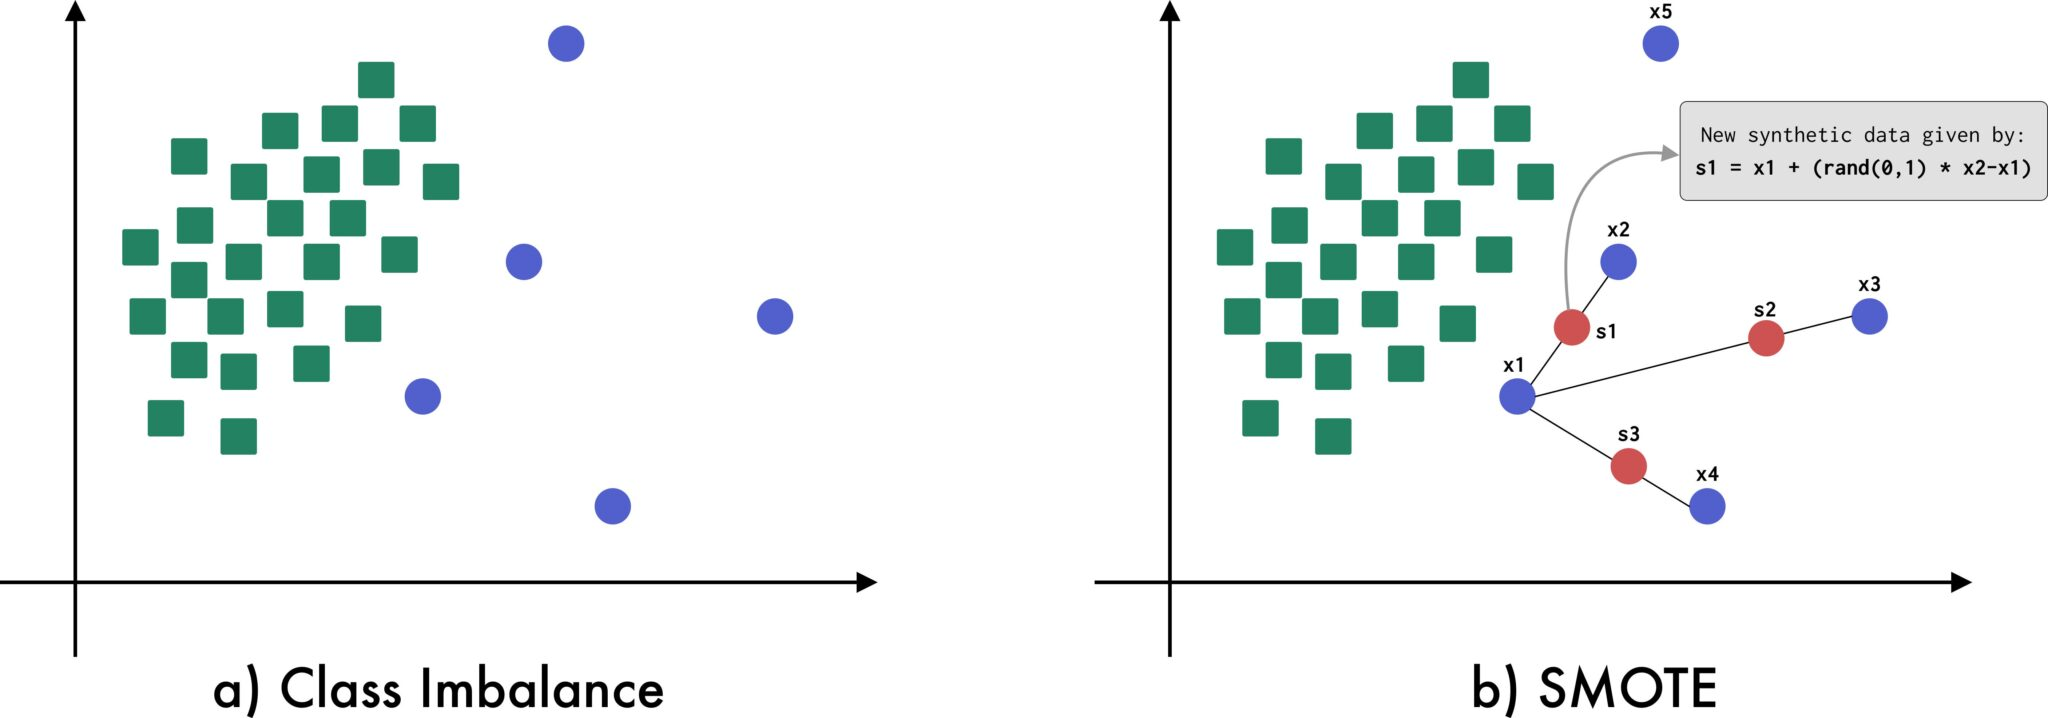

#### Advantages
- Generates new synthetic examples rather than duplicating existing ones
- Reduces overfitting compared to random oversampling
- Expands the decision boundary for minority class
- Often improves classifier performance on imbalanced datasets

#### Disadvantages
- May generate noisy or unrealistic samples
- Can increase class overlap if minority examples are surrounded by majority examples
- Assumes feature space is Euclidean (problematic for categorical features)
- Performance depends on the local density of minority examples

#### Implementation

In [31]:
# Using SMOTE
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Check new class distribution
smote_class_counts = pd.Series(y_train_smote).value_counts()
print("Class distribution after SMOTE:")
for cls, count in smote_class_counts.items():
    print(f"Class {cls}: {count} samples ({count/len(y_train_smote):.2%})")

Class distribution after SMOTE:
Class 0: 6276 samples (50.00%)
Class 1: 6276 samples (50.00%)


Let's visualize how SMOTE creates synthetic samples:

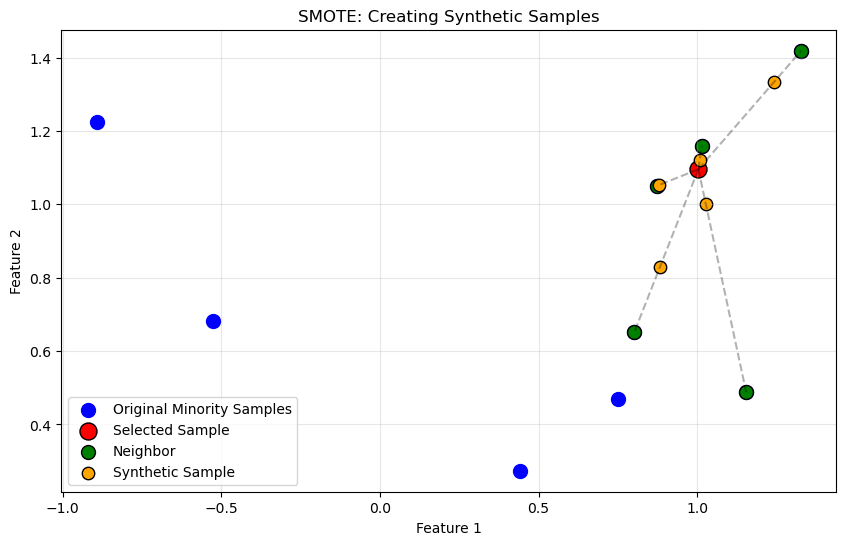

In [33]:
# Visualize SMOTE process
def plot_smote_example():
    """Visualize how SMOTE creates synthetic samples"""
    # Create a small subset for demonstration
    minority_samples = X_train[y_train == 1][:10]
    
    # Select one sample and its neighbors
    sample = minority_samples[0]
    # Find 5 nearest neighbors
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=6)  # 6 because it includes the point itself
    nn.fit(minority_samples)
    distances, indices = nn.kneighbors([sample])
    
    # Get neighbors (excluding the point itself)
    neighbors = [minority_samples[i] for i in indices[0][1:]]
    
    # Generate synthetic samples
    synthetic_samples = []
    for neighbor in neighbors:
        # Create sample at a random point between the sample and its neighbor
        alpha = np.random.random()
        synthetic_sample = sample + alpha * (neighbor - sample)
        synthetic_samples.append(synthetic_sample)
    
    # Visualize
    plt.figure(figsize=(10, 6))
    plt.scatter(minority_samples[:, 0], minority_samples[:, 1], 
                color='blue', s=100, label='Original Minority Samples')
    plt.scatter(sample[0], sample[1], color='red', s=150, 
                label='Selected Sample', edgecolors='black')
    
    for i, neighbor in enumerate(neighbors):
        plt.scatter(neighbor[0], neighbor[1], color='green', s=100,
                    label='Neighbor' if i == 0 else "", edgecolors='black')
        plt.plot([sample[0], neighbor[0]], [sample[1], neighbor[1]], 
                 'k--', alpha=0.3)
    
    for i, synthetic in enumerate(synthetic_samples):
        plt.scatter(synthetic[0], synthetic[1], color='orange', s=80,
                    label='Synthetic Sample' if i == 0 else "", edgecolors='black')
    
    plt.title('SMOTE: Creating Synthetic Samples')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the SMOTE visualization
plot_smote_example()

##### SMOTE Visualization Explanation

<details>
    <summary><b>Click to expand explanation of SMOTE visualization</b></summary>

This visualization illustrates how SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic samples:

- **Blue dots**: Original minority class samples in the dataset
- **Red dot**: A selected minority sample that SMOTE is using as a reference point
- **Green dots**: The nearest neighbors of the selected sample (also from the minority class)
- **Orange dots**: Newly created synthetic samples
- **Dashed gray lines**: Paths between the selected sample and its neighbors

The SMOTE algorithm works by:
1. Selecting a minority class sample (the red dot)
2. Finding its k-nearest neighbors from the same minority class (the green dots)
3. Creating new synthetic samples (orange dots) by interpolating along the lines between the sample and its neighbors

Each synthetic sample is created at a random point along the line connecting the original sample and one of its neighbors:
```python
synthetic_sample = sample + random_value * (neighbor - sample)

Now let's visualize our entire dataset after applying SMOTE:

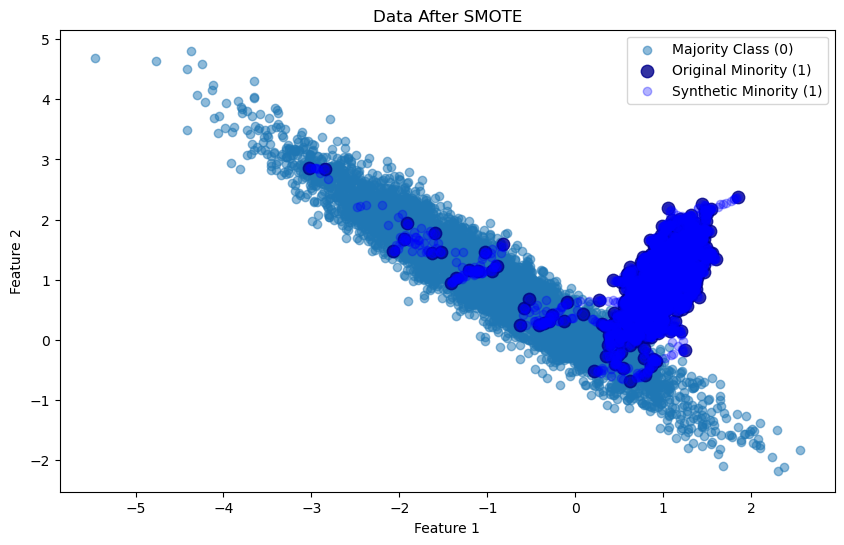

In [34]:
# Convert back to original feature space for visualization
X_train_smote_orig = scaler.inverse_transform(X_train_smote)

# Separate by class
X_train_smote_0 = X_train_smote_orig[y_train_smote == 0]
X_train_smote_1 = X_train_smote_orig[y_train_smote == 1]

# Get original minority class samples for comparison
X_train_1_orig = X_train[y_train == 1]

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_train_smote_0[:, 0], X_train_smote_0[:, 1], 
            alpha=0.5, label='Majority Class (0)')
plt.scatter(X_train_1_orig[:, 0], X_train_1_orig[:, 1], 
            color='darkblue', s=80, alpha=0.8, label='Original Minority (1)')
plt.scatter(X_train_smote_1[:, 0], X_train_smote_1[:, 1], 
            alpha=0.3, color='blue', label='Synthetic Minority (1)')
plt.title('Data After SMOTE')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

Now, let's train a model using the SMOTE-resampled data:

In [35]:
# Train model with SMOTE
smote_model = LogisticRegression(random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test_scaled)

# Evaluate
print("Model Performance with SMOTE:")
print(classification_report(y_test, y_pred_smote))

Model Performance with SMOTE:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2690
           1       0.89      0.95      0.92       310

    accuracy                           0.98      3000
   macro avg       0.94      0.97      0.96      3000
weighted avg       0.98      0.98      0.98      3000



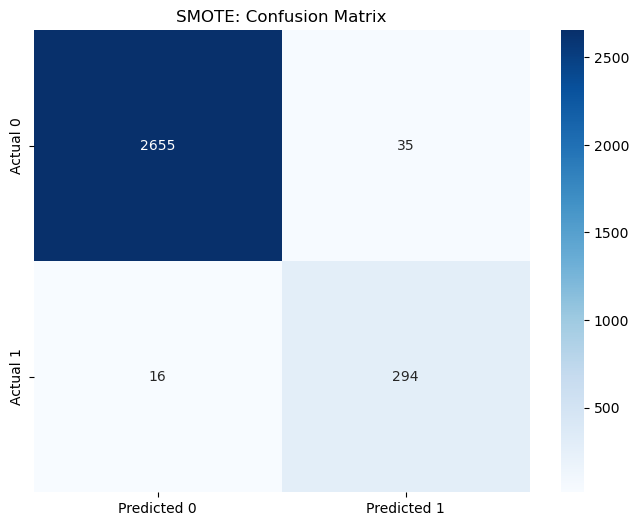

In [36]:
# Plot confusion matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('SMOTE: Confusion Matrix')
plt.show()

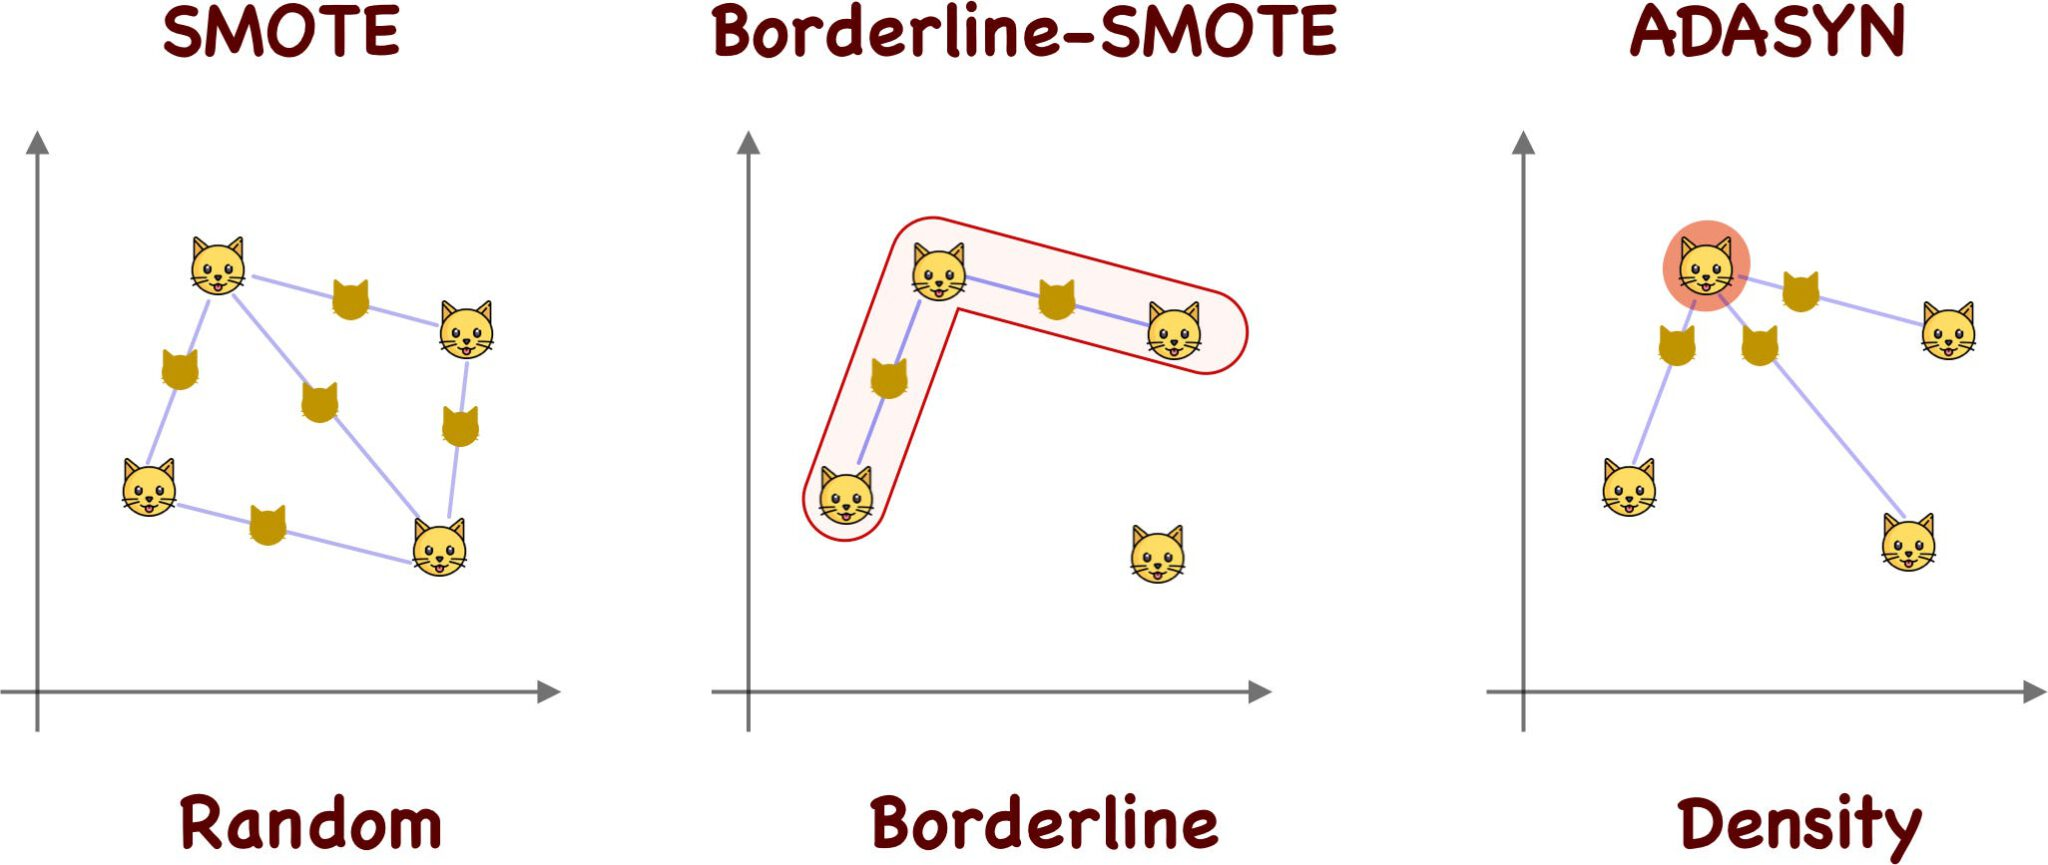

#### 1.3 Borderline-SMOTE

Borderline-SMOTE focuses on generating synthetic examples specifically for borderline instances (those near the decision boundary), which are more informative for classification.

##### Theory
- Identify borderline examples from the minority class:
  1. For each minority example, find its k nearest neighbors
  2. If most neighbors belong to the majority class, the example is considered a borderline example
- Apply SMOTE only to these borderline examples

##### Variants
- **Borderline-SMOTE1**: Considers only "danger" examples (those where more than half but not all neighbors are from majority class)
- **Borderline-SMOTE2**: Also considers examples where all neighbors are from majority class, but weights them differently


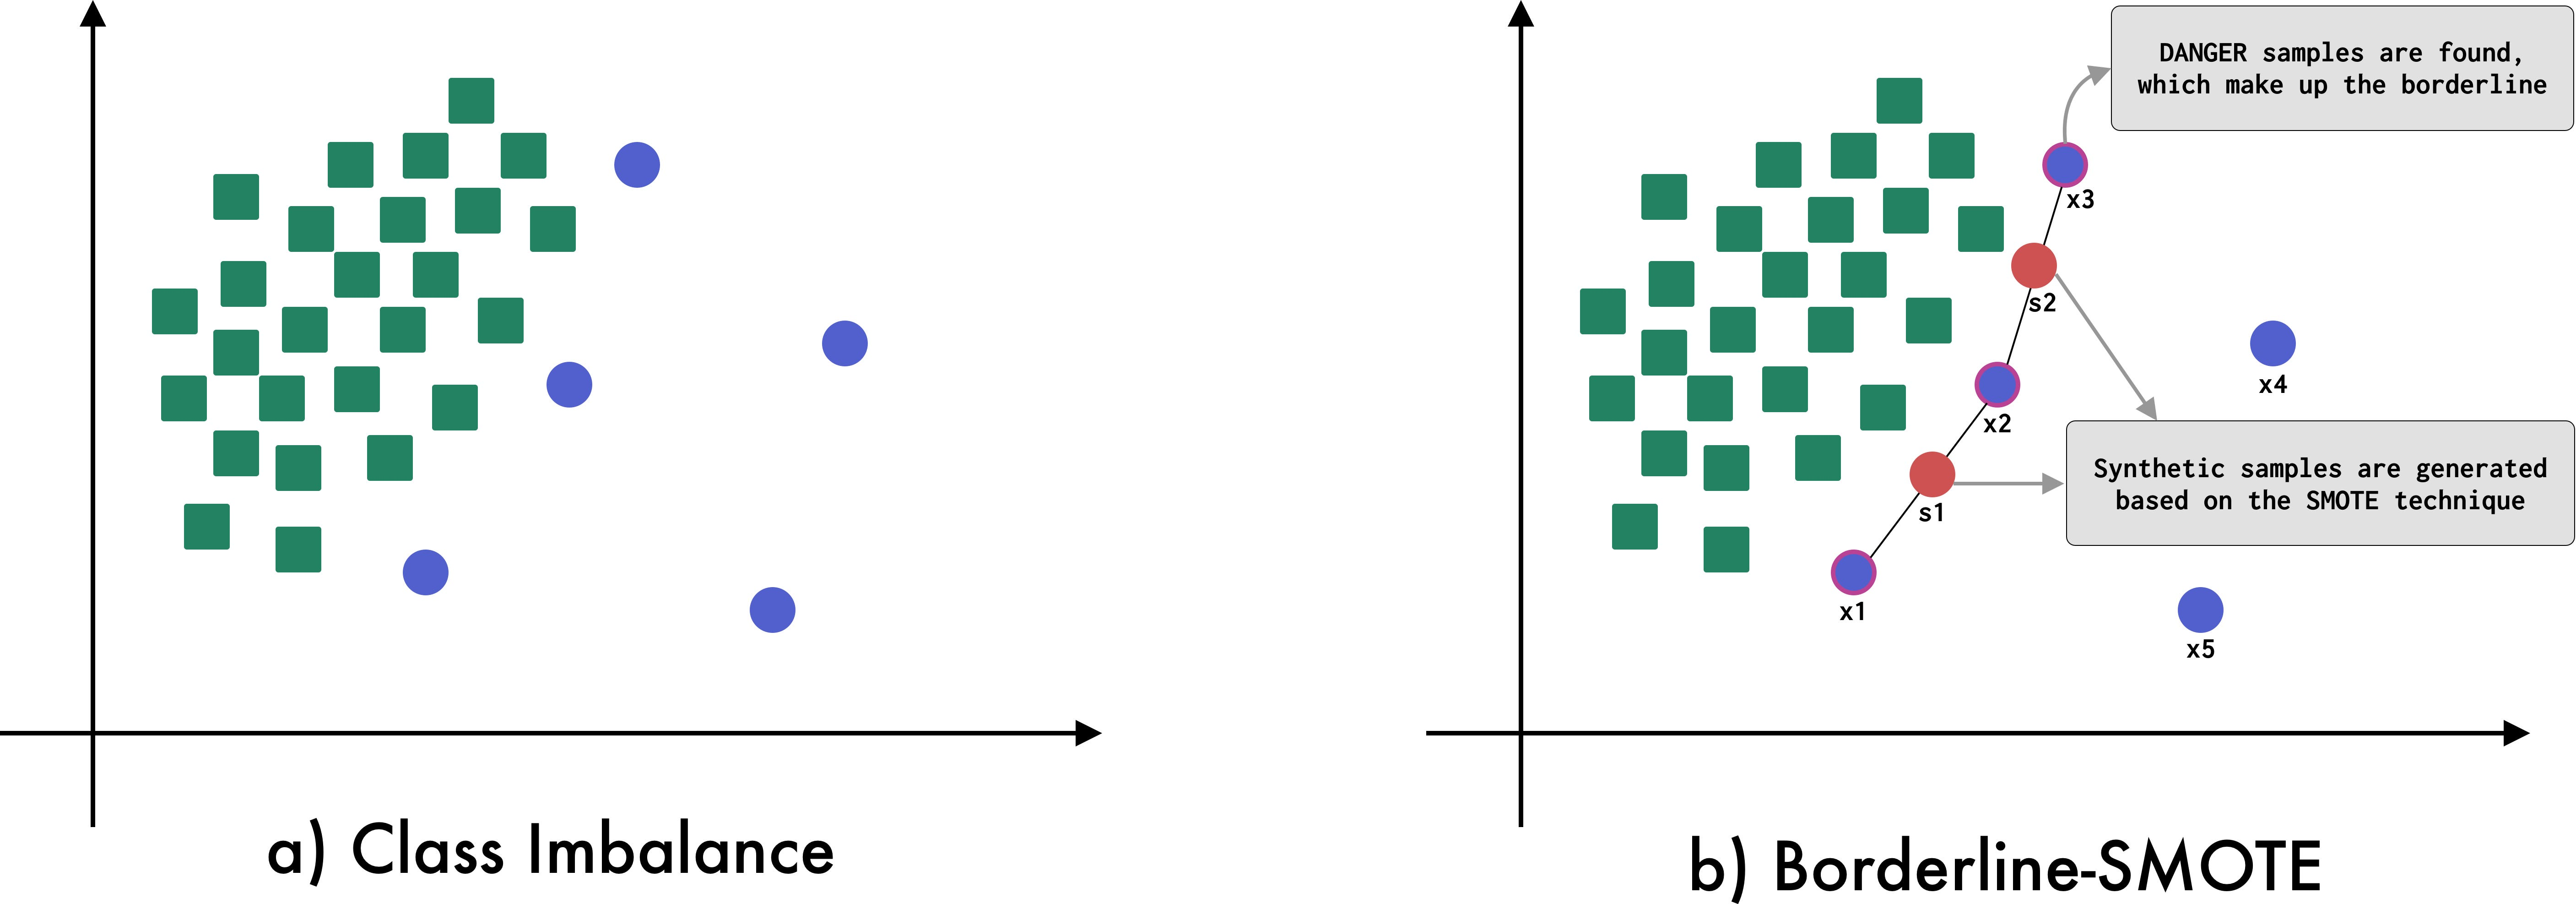

##### Advantages
- More focused sampling where it matters most (decision boundary)
- Less likely to introduce noise compared to standard SMOTE
- Often outperforms standard SMOTE
- Reduces unnecessary synthetic example generation in safe areas

##### Disadvantages
- More complex to implement
- Still can create unrealistic examples if features are correlated
- May still introduce noise if borderline detection is imperfect
- Computationally more expensive than standard SMOTE

##### Implementation

In [37]:
from imblearn.over_sampling import BorderlineSMOTE

# Create and apply Borderline-SMOTE
b_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = b_smote.fit_resample(X_train, y_train)

#### 1.4 ADASYN (Adaptive Synthetic Sampling)

ADASYN adaptively generates different numbers of synthetic samples for different minority instances based on their difficulty level.

##### Theory
- Calculate a density distribution based on difficulty level of each minority instance
- Generate synthetic examples based on this distribution:
  1. More synthetic examples for minority instances that are harder to learn
  2. Fewer synthetic examples for easier instances
- "Difficulty" is determined by how many majority class neighbors an instance has

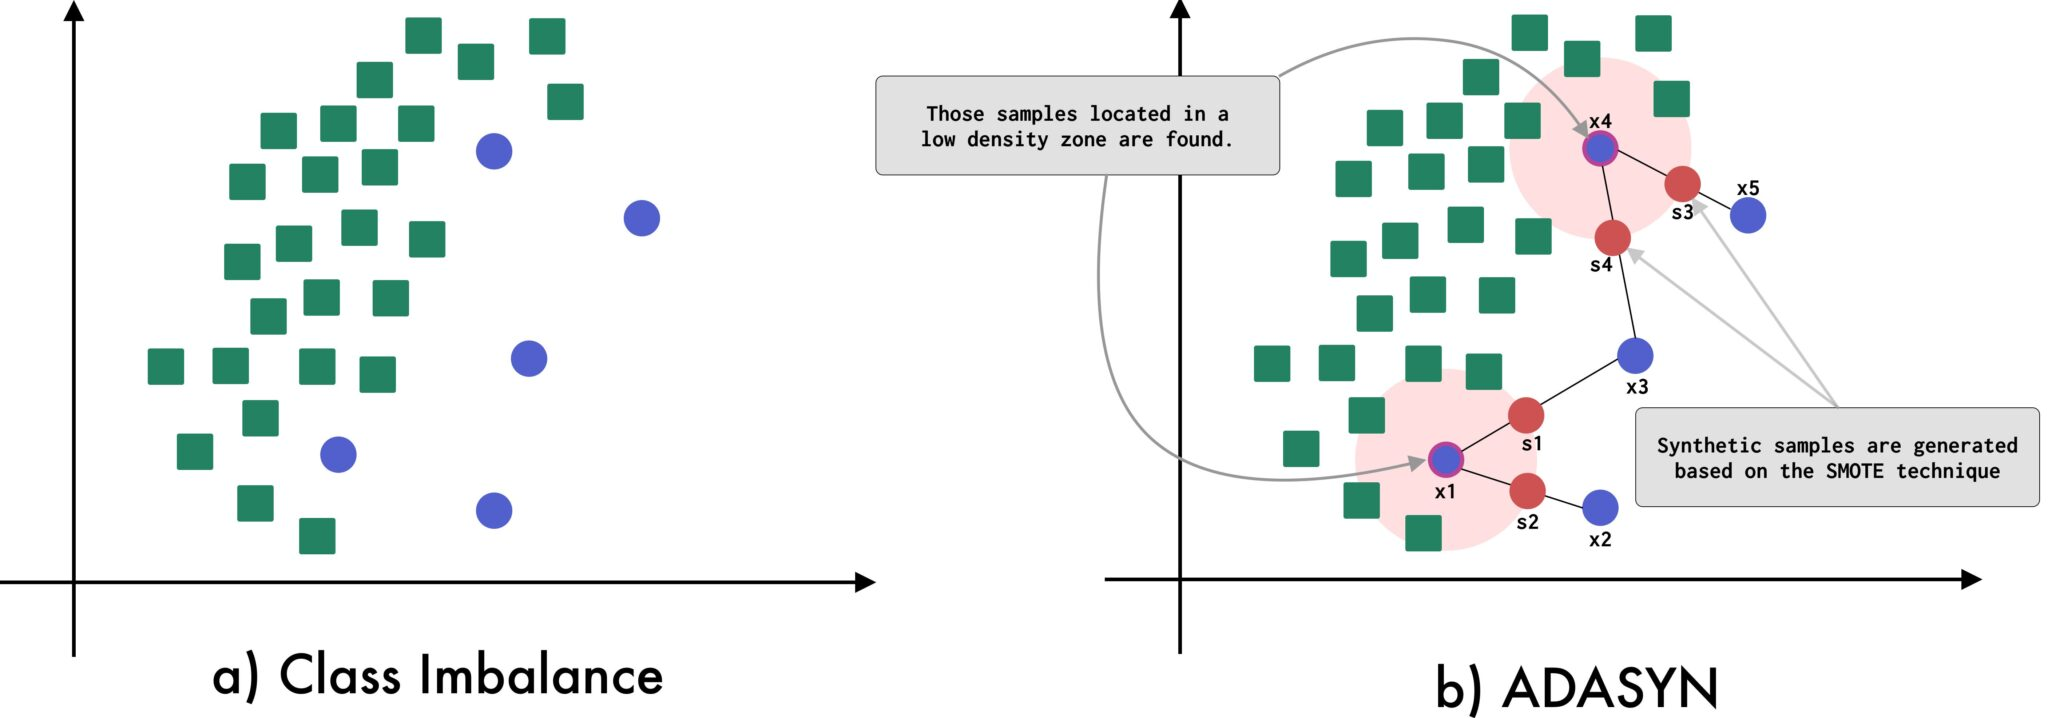

##### Advantages
- Adaptively focuses on difficult examples
- Creates more diverse synthetic examples where they're most needed
- Can improve decision boundary in complex regions
- Further reduces bias compared to standard SMOTE

##### Disadvantages
- May overemphasize outliers (if they're surrounded by majority examples)
- Complex implementation
- Higher computational cost
- Can increase noise if difficulty measure is misleading

##### Implementation

In [38]:
from imblearn.over_sampling import ADASYN

# Create and apply ADASYN
adasyn = ADASYN(sampling_strategy='auto', n_neighbors=5, random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)

### 2. Undersampling Techniques

Undersampling reduces the number of majority class instances to balance the class distribution. This approach can be particularly useful when dealing with very large datasets.

#### 2.1 Random Undersampling

Random undersampling removes examples from the majority class randomly until a desired balance is achieved.

##### Theory
- Randomly select examples from the majority class without replacement
- Remove these examples to decrease the majority class size
- Continue until target distribution is reached

##### Advantages
- Simple to implement and understand
- Reduces training time by decreasing dataset size
- Can help when majority class has redundant examples
- Mitigates computational burden for large datasets

##### Disadvantages
- Potential loss of important information
- Risk of discarding useful examples near decision boundary
- May lead to underfitting
- Can create a non-representative sample of the majority class

##### Implementation

In [39]:
# Random undersampling
from imblearn.under_sampling import RandomUnderSampler

# Apply random undersampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

# Check new class distribution
rus_class_counts = pd.Series(y_train_rus).value_counts()
print("Class distribution after random undersampling:")
for cls, count in rus_class_counts.items():
    print(f"Class {cls}: {count} samples ({count/len(y_train_rus):.2%})")

Class distribution after random undersampling:
Class 0: 724 samples (50.00%)
Class 1: 724 samples (50.00%)


Let's visualize the data after random undersampling:

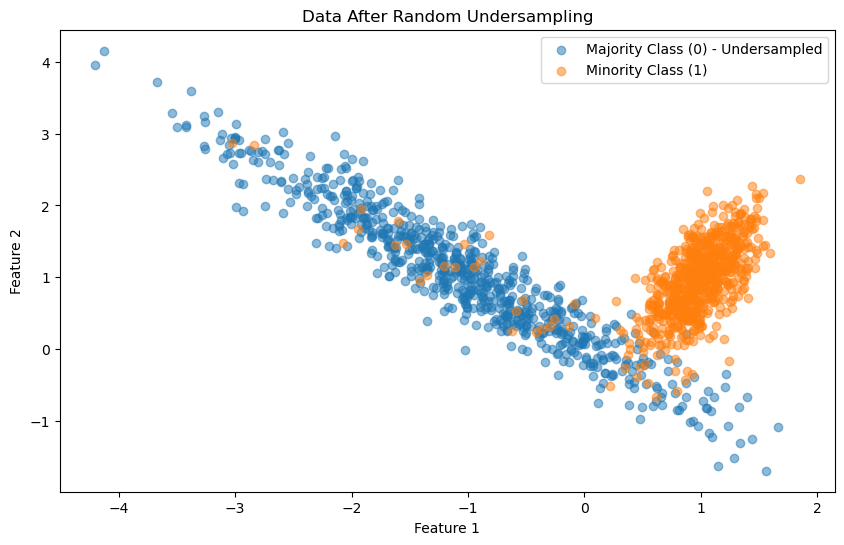

In [40]:
# Convert back to original feature space for visualization
X_train_rus_orig = scaler.inverse_transform(X_train_rus)

# Separate by class
X_train_rus_0 = X_train_rus_orig[y_train_rus == 0]
X_train_rus_1 = X_train_rus_orig[y_train_rus == 1]

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_train_rus_0[:, 0], X_train_rus_0[:, 1], 
            alpha=0.5, label='Majority Class (0) - Undersampled')
plt.scatter(X_train_rus_1[:, 0], X_train_rus_1[:, 1], 
            alpha=0.5, label='Minority Class (1)')
plt.title('Data After Random Undersampling')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

Now let's train a model on the undersampled data:

Model Performance with Random Undersampling:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2690
           1       0.87      0.95      0.91       310

    accuracy                           0.98      3000
   macro avg       0.93      0.97      0.95      3000
weighted avg       0.98      0.98      0.98      3000



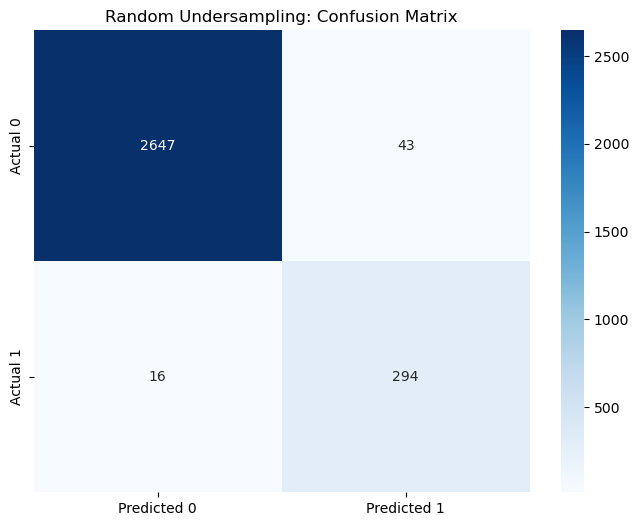

In [41]:
# Train model with random undersampling
rus_model = LogisticRegression(random_state=42)
rus_model.fit(X_train_rus, y_train_rus)
y_pred_rus = rus_model.predict(X_test_scaled)

# Evaluate
print("Model Performance with Random Undersampling:")
print(classification_report(y_test, y_pred_rus))

# Plot confusion matrix
cm_rus = confusion_matrix(y_test, y_pred_rus)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rus, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Random Undersampling: Confusion Matrix')
plt.show()

#### 2.2 Tomek Links

Tomek links are pairs of examples from different classes that are nearest neighbors of each other. Removing majority examples from these pairs can help clean class boundaries.

##### Theory
- A Tomek link occurs when two examples of different classes are nearest neighbors
- These examples are likely at the boundary between classes or represent noise
- Remove the majority class examples from identified Tomek links

##### Advantages
- Focused removal of examples that might confuse the classifier
- Improves separation between classes
- Only removes examples that might lead to misclassification
- Preserves most information in the majority class

##### Disadvantages
- May not reduce dataset size significantly if few Tomek links exist
- More computationally expensive than random undersampling
- Can be ineffective for high-dimensional data
- Depends on distance metric, which may not work well for all feature types

##### Implementation

In [42]:
from imblearn.under_sampling import TomekLinks

# Create and apply Tomek Links
tl = TomekLinks(sampling_strategy='auto')
X_resampled, y_resampled = tl.fit_resample(X_train, y_train)

#### 2.3 Edited Nearest Neighbors (ENN)

ENN removes examples from the majority class that are misclassified by their nearest neighbors, effectively removing noise and outliers.

##### Theory
- For each example in the dataset:
  1. Find its k nearest neighbors
  2. If the example is from the majority class and is misclassified by the majority vote of its neighbors, remove it

##### Advantages
- Removes noisy examples that could harm classification
- Smooths the decision boundary
- Preserves examples that are correctly classified by their neighbors
- Better than random undersampling for preserving important information

##### Disadvantages
- Can be computationally expensive for large datasets
- Effectiveness depends on the choice of k for nearest neighbors
- May not reduce the dataset size enough for extreme imbalance
- Sensitive to noise in the minority class

##### Implementation

In [43]:
from imblearn.under_sampling import EditedNearestNeighbours

# Create and apply ENN
enn = EditedNearestNeighbours(sampling_strategy='auto', n_neighbors=3)
X_resampled, y_resampled = enn.fit_resample(X_train, y_train)

### 3. Combined Approaches

Combined approaches leverage both oversampling and undersampling techniques to achieve better results than either approach alone.

#### 3.1 SMOTE-Tomek

SMOTE-Tomek first applies SMOTE to oversample the minority class, then removes Tomek links to clean the resulting distribution.

##### Theory
- Apply SMOTE to generate synthetic minority examples
- Identify Tomek links in the resulting dataset
- Remove majority examples from these Tomek links

##### Advantages
- Increases minority class size while cleaning decision boundaries
- Addresses both imbalance and potential overlap
- Often outperforms either SMOTE or Tomek links alone
- Creates cleaner decision boundaries

##### Disadvantages
- Computationally expensive
- Complex implementation
- May still suffer from some of SMOTE's limitations
- Two-step process can be hard to tune

##### Implementation

In [44]:
# Combining SMOTE and Tomek Links
from imblearn.combine import SMOTETomek

# Apply SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train_scaled, y_train)

# Check new class distribution
st_class_counts = pd.Series(y_train_st).value_counts()
print("Class distribution after SMOTETomek:")
for cls, count in st_class_counts.items():
    print(f"Class {cls}: {count} samples ({count/len(y_train_st):.2%})")

Class distribution after SMOTETomek:
Class 0: 6141 samples (50.00%)
Class 1: 6141 samples (50.00%)


Let's train a model using this combined approach:

In [45]:
# Train model with SMOTETomek
st_model = LogisticRegression(random_state=42)
st_model.fit(X_train_st, y_train_st)
y_pred_st = st_model.predict(X_test_scaled)

# Evaluate
print("Model Performance with SMOTETomek:")
print(classification_report(y_test, y_pred_st))

Model Performance with SMOTETomek:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2690
           1       0.92      0.95      0.93       310

    accuracy                           0.99      3000
   macro avg       0.95      0.97      0.96      3000
weighted avg       0.99      0.99      0.99      3000



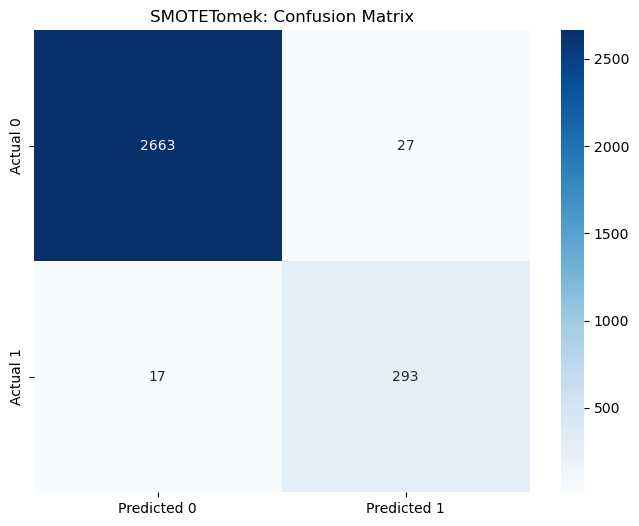

In [46]:
# Plot confusion matrix
cm_st = confusion_matrix(y_test, y_pred_st)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_st, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('SMOTETomek: Confusion Matrix')
plt.show()

#### 3.2 SMOTE-ENN

SMOTE-ENN first applies SMOTE for oversampling, then uses Edited Nearest Neighbors to remove examples that might increase class overlap.

##### Theory
- Apply SMOTE to generate synthetic minority examples
- Apply ENN to remove noisy examples (from both classes)

##### Advantages
- More aggressive cleaning than SMOTE-Tomek
- Can remove noise from both majority and minority classes
- Often creates cleaner decision boundaries
- Addresses limitations of both SMOTE and imbalanced data

##### Disadvantages
- Very computationally expensive
- Can remove too many examples
- May not preserve all synthetic examples generated by SMOTE
- Complex to tune effectively

##### Implementation

In [47]:
from imblearn.combine import SMOTEENN

# Create and apply SMOTE-ENN
smote_enn = SMOTEENN(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)

#### 3.3 SMOTE with Different Variants and Cleaning

Many custom combinations can be created, such as:
- Borderline-SMOTE with Tomek links
- ADASYN with ENN
- SVM-SMOTE with NCR

##### Implementation Example (Custom Pipeline)

In [48]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import TomekLinks

# Create a pipeline with BorderlineSMOTE followed by Tomek Links
pipeline = Pipeline([
    ('over', BorderlineSMOTE(random_state=42)),
    ('under', TomekLinks())
])

# Apply the pipeline
X_resampled, y_resampled = pipeline.fit_resample(X_train, y_train)

### Important Note on Data-Level Approaches for Handling Imbalance

#### ⚠️ Apply Resampling Only to Training Data

**All data-level approaches** discussed (oversampling, undersampling, and combined techniques) should be applied **only to the training data**, never to the entire dataset before splitting. This is a critical methodological requirement that applies to:

##### Oversampling Techniques
- Random Oversampling
- SMOTE and all variants (Borderline-SMOTE, ADASYN, SVM-SMOTE, etc.)
- All synthetic sample generation methods

##### Undersampling Techniques
- Random Undersampling
- Tomek Links
- ENN, RENN, All-KNN
- CNN, OSS, NCR, Near Miss
- Instance Hardness Threshold

##### Combined Approaches
- SMOTE-Tomek
- SMOTE-ENN
- All hybrid and ensemble methods

#### Why This Matters

1. **Prevents data leakage**: Applying resampling before splitting allows information from test instances to influence training data through synthetic samples or removal decisions.

2. **Maintains test set integrity**: Your test set should reflect the real-world data distribution you'll encounter in production.

3. **Avoids overly optimistic results**: Data leakage can significantly inflate performance metrics, giving a false sense of model quality.

4. **Reflects real-world application**: In practice, you would never have access to future unseen data to inform your resampling strategy.

#### Correct Implementation

```python
# Correct approach
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. First split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Then apply resampling ONLY to training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 3. Train model on resampled training data
model.fit(X_train_resampled, y_train_resampled)

# 4. Evaluate on original test data (not resampled)
y_pred = model.predict(X_test)
```

#### Incorrect Implementation (Avoid This)

```python
# INCORRECT approach (leads to data leakage)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# DON'T resample before splitting
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)  # WRONG!

# Splitting after resampling causes leakage
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)  # WRONG!
```

#### Remember
The goal is to create a model that performs well on real-world imbalanced data, not on artificially balanced test data.
```

### 4. Practical Considerations and Best Practices

#### 4.1 Evaluation in Imbalanced Settings

When evaluating models trained on resampled data, consider:

- **Use appropriate metrics**: Accuracy is misleading for imbalanced data. Instead, use:
  - Precision, Recall, F1-score
  - AUC-ROC and AUC-PR (Precision-Recall)
  - Cohen's Kappa
  - Balanced accuracy
  - G-mean

- **Stratified cross-validation**: Ensure class proportions are maintained across folds

- **Apply resampling inside cross-validation**: To prevent data leakage, apply resampling only to training data in each fold

#### 4.2 Choosing the Right Approach

- **Dataset size**: For small datasets, oversampling may be preferred to avoid information loss
- **Imbalance ratio**: Extreme imbalance might require combined approaches
- **Domain knowledge**: Some domains have specific requirements about false positives vs. false negatives
- **Data distribution**: Consider if the minority class consists of rare subclusters or rare examples

#### 4.3 Preprocessing Considerations

- **Handle outliers** before applying resampling techniques
- **Scale features** before distance-based methods like SMOTE
- **Encode categorical variables** appropriately
- **Consider dimensionality reduction** for high-dimensional data

#### 4.4 Implementation Example with Cross-Validation

## Algorithm-level Approaches for Handling Class Imbalance

Unlike data-level approaches that modify the training dataset, algorithm-level approaches directly modify the learning algorithm to address class imbalance. These techniques aim to make classifiers more sensitive to the minority class without altering the original data distribution.

### 1. Cost-Sensitive Learning

Cost-sensitive learning methods assign different misclassification costs to different classes, making classifiers more sensitive to errors on the minority class.

#### 1.1 Class Weighting

Class weighting assigns higher weights to minority class examples during model training, effectively increasing their importance in the optimization process.

##### Theory
- Modify the objective function to incorporate weights for different classes
- Higher weights for minority class examples make their misclassification more "expensive"
- The classifier optimizes toward a weighted error rather than a standard error

##### Advantages
- Preserves all original data without modification
- Simple to implement (built into many ML libraries)
- Adapts the algorithm rather than the data
- Maintains the original data distribution
- Can be fine-tuned to achieve desired precision-recall trade-offs

##### Disadvantages
- Finding optimal weights can be challenging
- May not work well for extremely imbalanced datasets
- Not all algorithms support class weighting
- Performance depends on the base classifier

##### Implementation

In [52]:
# Using class weights with logistic regression
class_weights = {0: 1, 1: 10}  # Penalize minority class misclassification 10x more
weighted_model = LogisticRegression(class_weight=class_weights, random_state=42)
weighted_model.fit(X_train_scaled, y_train)
y_pred_weighted = weighted_model.predict(X_test_scaled)

# Evaluate
print("Model Performance with Manual Class Weights:")
print(classification_report(y_test, y_pred_weighted))

Model Performance with Manual Class Weights:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2690
           1       0.86      0.95      0.90       310

    accuracy                           0.98      3000
   macro avg       0.93      0.97      0.95      3000
weighted avg       0.98      0.98      0.98      3000



##### Cost-Sensitive Learning with Class Weights

<details>
    <summary><b>Click to expand explanation</b></summary>

This code implements cost-sensitive learning, an algorithm-level approach to handling class imbalance:

1. **Setting Class Weights**:
   - `class_weights = {0: 1, 1: 10}` creates an asymmetric cost ratio
   - Class 0 (non-fraud): weight = 1
   - Class 1 (fraud): weight = 10 (10× more costly to misclassify)

2. **How Class Weights Work**:
   - During model training, errors on minority class examples contribute 10× more to the loss function
   - This effectively tells the model: "Pay more attention to the minority class"
   - The decision boundary shifts toward the majority class, increasing minority class recall

3. **Benefits in Fraud Detection**:
   - Reflects the real-world cost asymmetry (missing fraud is more costly than false alarms)
   - Keeps the original data distribution intact (no sampling required)
   - Works well when class imbalance is severe (e.g., fraud detection with 0.1-0.2% fraud)

4. **Implementation Notes**:
   - Can also use `class_weight='balanced'` to automatically calculate weights inversely proportional to class frequencies
   - Many scikit-learn classifiers support the `class_weight` parameter (SVM, Random Forest, etc.)
   - The optimal weight ratio depends on your specific business costs and dataset

This is a popular approach in fraud detection because it directly encodes the business priority (catching fraud) into the model without changing the underlying data distribution.
</details>

In [53]:
# Or let scikit-learn determine balanced weights automatically
balanced_model = LogisticRegression(class_weight='balanced', random_state=42)
balanced_model.fit(X_train_scaled, y_train)
y_pred_balanced = balanced_model.predict(X_test_scaled)

# Evaluate
print("\nModel Performance with 'balanced' Class Weights:")
print(classification_report(y_test, y_pred_balanced))


Model Performance with 'balanced' Class Weights:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2690
           1       0.88      0.95      0.91       310

    accuracy                           0.98      3000
   macro avg       0.94      0.97      0.95      3000
weighted avg       0.98      0.98      0.98      3000



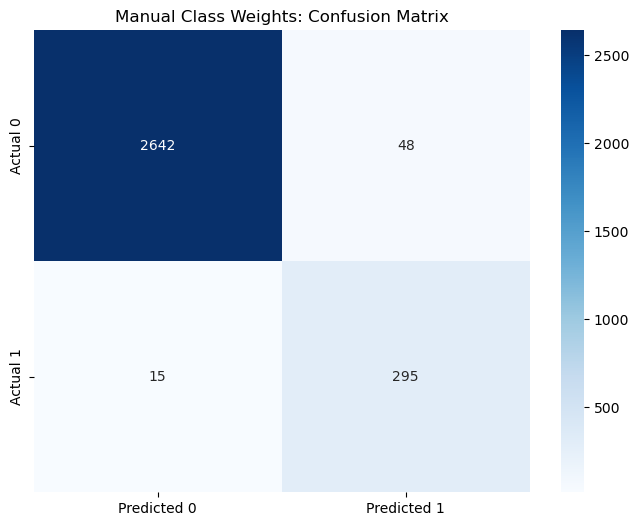

In [54]:
# Plot confusion matrix
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Manual Class Weights: Confusion Matrix')
plt.show()

### Finding Optimal Weights

The optimal class weights depend on the specific problem and can be determined through cross-validation.

In [56]:
# Finding optimal class weights through grid search
from sklearn.model_selection import GridSearchCV

# Define a range of class weights to try
param_grid = {
    'class_weight': [
        {0: 1, 1: 1},
        {0: 1, 1: 5},
        {0: 1, 1: 10},
        {0: 1, 1: 20},
        'balanced'
    ]
}

# Create grid search
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',  # Using F1 score which balances precision and recall
    n_jobs=-1
)

# Fit to find the best weights
grid_search.fit(X_train_scaled, y_train)

# Print the best parameter
print(f"Best class weight: {grid_search.best_params_}")
print(f"Best F1 score: {grid_search.best_score_:.4f}")

Best class weight: {'class_weight': {0: 1, 1: 1}}
Best F1 score: 0.9374


In [57]:
# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print("\nTest Performance with Best Class Weights:")
print(classification_report(y_test, y_pred_best))


Test Performance with Best Class Weights:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2690
           1       1.00      0.89      0.94       310

    accuracy                           0.99      3000
   macro avg       0.99      0.95      0.97      3000
weighted avg       0.99      0.99      0.99      3000



#### 1.2 Cost-Sensitive Decision Trees

Decision trees can be modified to become cost-sensitive by adjusting the splitting criteria to account for misclassification costs.

##### Theory
- Modify the splitting criteria (e.g., Gini index or entropy) to incorporate class weights
- Adjust the leaf node predictions to minimize the expected misclassification cost
- Prune trees based on cost-complexity considerations

##### Advantages
- Cost sensitivity built directly into the tree-building process
- Can handle different misclassification costs for each class pair
- Often performs better than applying class weights to standard trees
- Maintains interpretability of decision trees

##### Disadvantages
- More complex implementation
- May create larger trees to capture minority patterns
- Requires careful tuning to avoid overfitting
- Less common in standard libraries

##### Implementation

In [58]:
# Example with scikit-learn's weighted Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create a weighted decision tree
# 'balanced' adjusts weights inversely proportional to class frequencies
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

# Alternatively, specify weights manually
weights = {0: 1, 1: 9}
dt = DecisionTreeClassifier(class_weight=weights, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 1, 1: 9}, random_state=42)

## Threshold Adjustment

A simple but effective approach is to adjust the classification threshold for the positive class.

These methods modify the classification threshold after a probabilistic model has been trained.

### 1 ROC Curve Analysis

ROC (Receiver Operating Characteristic) curve analysis finds the optimal threshold based on the trade-off between true positive rate and false positive rate.

#### Theory
- Train a probabilistic classifier that outputs class probabilities
- Generate an ROC curve by plotting the true positive rate vs. false positive rate at different thresholds
- Select a threshold that optimizes a specific metric (e.g., balanced accuracy) or achieves a desired trade-off

#### Advantages
- Can be applied to any probabilistic classifier post-training
- Provides a visual representation of classifier performance
- Allows for flexible decision-making based on costs of different error types
- Simple to implement with many visualization libraries

#### Disadvantages
- Requires probabilistic outputs from the classifier
- Not applicable to models that only provide hard classifications
- May not work well when class distributions change between training and deployment
- ROC curves can be misleading for highly imbalanced datasets

#### Implementation

In [2]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Train a probabilistic classifier
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Get predicted probabilities for the positive class
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

# Find threshold that maximizes the geometric mean of sensitivity and specificity
gmeans = np.sqrt(tpr * (1 - fpr))
ix = np.argmax(gmeans)
optimal_threshold = thresholds[ix]
print(f'Optimal Threshold: {optimal_threshold:.4f}')
plt.plot(fpr[ix], tpr[ix], 'o', markersize=8, color='red', 
         label=f'Optimal Threshold: {optimal_threshold:.4f}')
plt.legend()
plt.show()

# Apply the optimal threshold to make predictions
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

NameError: name 'X_train' is not defined

##### Threshold Optimization Using ROC Curve Analysis

<details>
    <summary><b>Click to expand explanation</b></summary>

This code implements threshold adjustment, an algorithm-level approach for handling class imbalance:

1. **Model Training**:
   - Trains a logistic regression classifier (without any class imbalance handling)
   - Extracts predicted probabilities for the positive class (fraud)

2. **ROC Curve Calculation**:
   - `roc_curve()` calculates False Positive Rate (FPR) and True Positive Rate (TPR) at different thresholds
   - `roc_auc_score()` calculates the Area Under the Curve (AUC) - a threshold-independent metric

3. **Finding the Optimal Threshold**:
   - Standard classifiers use a default threshold of 0.5
   - This code finds a better threshold using the geometric mean: G-mean = √(TPR × (1-FPR))
   - G-mean balances sensitivity (catching fraud) and specificity (avoiding false alarms)
   - `optimal_threshold = thresholds[ix]` selects the threshold with maximum G-mean

4. **Visualization**:
   - Plots the ROC curve showing trade-offs between true and false positive rates
   - Diagonal line represents a random classifier
   - Red dot shows the optimal threshold

5. **Threshold Application**:
   - Uses the optimal threshold instead of the default 0.5 to make final predictions
   - `y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)`

This approach is effective because it doesn't change the model itself, but adjusts how predictions are made based on your specific performance requirements. For fraud detection, where typical thresholds are too conservative, this often significantly improves recall while maintaining acceptable precision.
</details>

### 2 Precision-Recall Curve Analysis

Precision-Recall (PR) curve analysis is often more appropriate than ROC curves for imbalanced datasets.

#### Theory
- Train a probabilistic classifier that outputs class probabilities
- Generate a PR curve by plotting precision vs. recall at different thresholds
- Select a threshold that optimizes a specific metric (e.g., F1-score) or achieves a desired trade-off

#### Advantages
- Better suited for imbalanced datasets than ROC curves
- Provides a clear view of precision-recall trade-offs
- Focuses on the performance on the minority class
- Can be used to select thresholds based on business requirements

#### Disadvantages
- Still requires probabilistic outputs from the classifier
- More sensitive to changes in class distribution
- May be harder to interpret for non-technical stakeholders
- Less common in some domains than ROC analysis

#### Implementation

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for the positive class
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate Average Precision (AP)
ap = average_precision_score(y_test, y_pred_proba)

# Plot Precision-Recall curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {ap:.2f})')
plt.axhline(y=sum(y_test)/len(y_test), color='gray', linestyle='--', 
            label=f'Baseline (Minority class ratio: {sum(y_test)/len(y_test):.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

# Find threshold that maximizes F1 score
# Add a small epsilon to thresholds to handle the case where precision and recall arrays are longer
thresholds = np.append(thresholds, 0)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
ix = np.argmax(f1_scores)
optimal_threshold = thresholds[ix]
print(f'Optimal Threshold (Max F1): {optimal_threshold:.4f}')
plt.plot(recall[ix], precision[ix], 'o', markersize=8, color='red', 
         label=f'Optimal Threshold: {optimal_threshold:.4f}')
plt.legend()
plt.show()

# Apply the optimal threshold to make predictions
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

##### Threshold Optimization Using Precision-Recall Curves

<details>
    <summary><b>Click to expand explanation</b></summary>

This code implements threshold adjustment using Precision-Recall curves, particularly valuable for imbalanced datasets:

1. **Why Precision-Recall Curves?**
   - Unlike ROC curves, PR curves focus directly on the minority class performance
   - More informative than ROC when classes are highly imbalanced (like fraud detection)
   - The baseline (gray dashed line) represents the performance of a random classifier
   - Area under PR curve (Average Precision) is a better metric for imbalanced problems

2. **Curve Calculation**:
   - `precision_recall_curve()` calculates precision and recall at different thresholds
   - `average_precision_score()` calculates the area under the PR curve
   - Precision = TP/(TP+FP) (how many predicted positives are correct)
   - Recall = TP/(TP+FN) (how many actual positives are caught)

3. **Finding the Optimal Threshold**:
   - Calculates F1 score at each threshold: F1 = 2 * (precision * recall) / (precision + recall)
   - F1 score balances precision and recall
   - `optimal_threshold = thresholds[ix]` selects the threshold that maximizes F1
   - The red dot on the curve shows this optimal threshold

4. **Implementation Details**:
   - `np.append(thresholds, 0)` handles an edge case where precision/recall arrays have different lengths
   - `1e-10` is added to denominator to prevent division by zero
   - Final predictions use the optimal threshold instead of the default 0.5

For severely imbalanced problems like fraud detection, precision-recall curves are typically more informative than ROC curves, as they don't consider true negatives (which overwhelm the metrics in imbalanced settings). The optimal threshold found using F1 score often provides a better balance between catching fraud and minimizing false alarms.
</details>

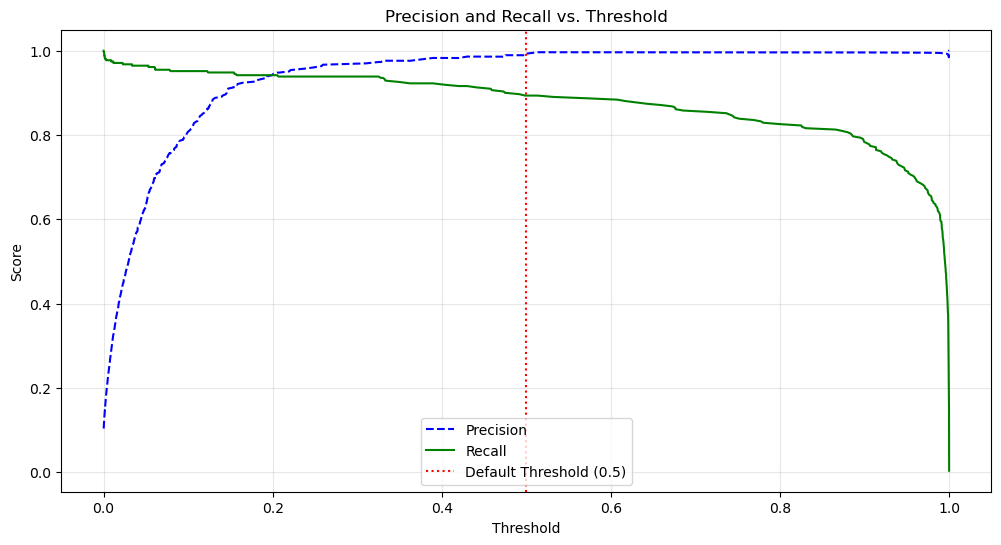

Optimal threshold (where precision ≈ recall): 0.1989
At this threshold, precision ≈ 0.9419, recall ≈ 0.9419


In [59]:
# Threshold adjustment
def plot_precision_recall_vs_threshold():
    # Get probabilities
    y_scores = baseline_model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate precision and recall for different thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision and Recall vs. Threshold')
    plt.axvline(x=0.5, color='r', linestyle=':', label='Default Threshold (0.5)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Find the threshold where precision and recall are balanced
    differences = np.abs(precision[:-1] - recall[:-1])
    min_diff_idx = np.argmin(differences)
    optimal_threshold = thresholds[min_diff_idx]
    
    print(f"Optimal threshold (where precision ≈ recall): {optimal_threshold:.4f}")
    print(f"At this threshold, precision ≈ {precision[min_diff_idx]:.4f}, recall ≈ {recall[min_diff_idx]:.4f}")
    
    return optimal_threshold

# Plot precision-recall vs threshold
optimal_threshold = plot_precision_recall_vs_threshold()

##### Precision-Recall Balance Threshold Optimization

<details>
    <summary><b>Click to expand explanation</b></summary>

This code implements threshold optimization by finding the balance point between precision and recall:

1. **Function Purpose**:
   - Creates a visual and numerical way to select an optimal classification threshold
   - Default threshold (0.5) is often unsuitable for imbalanced problems like fraud detection

2. **Visualization Component**:
   - Plots precision and recall across all possible threshold values
   - Blue dashed line: Precision (% of predicted fraud that is actual fraud)
   - Green solid line: Recall (% of actual fraud that is caught)
   - Red vertical line: Default threshold (0.5)
   - As threshold ↑: Precision ↑, Recall ↓
   - As threshold ↓: Precision ↓, Recall ↑

3. **Optimal Threshold Selection**:
   - Finds the threshold where precision and recall are approximately equal
   - `differences = np.abs(precision[:-1] - recall[:-1])`
   - `min_diff_idx = np.argmin(differences)`
   - This balancing point is often a good compromise for imbalanced classification
   - Alternative to F1-optimization or G-mean optimization

4. **Why This Works**:
   - In fraud detection, the default threshold (0.5) is usually too high
   - This method finds a threshold where false positives and false negatives are more balanced
   - Particularly useful when the costs of false positives and false negatives are similar
   - For fraud, if missing fraud is more costly than false alarms, you might want a lower threshold

This approach provides a data-driven, visually intuitive way to select a classification threshold without changing the underlying model, making it an effective algorithm-level approach to handling class imbalance.
</details>

Now, let's apply this optimal threshold to our predictions:

In [61]:
# Apply the optimal threshold
y_scores = baseline_model.predict_proba(X_test_scaled)[:, 1]
y_pred_optimal = (y_scores >= optimal_threshold).astype(int)

# Evaluate
print("Model Performance with Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal))

Model Performance with Optimal Threshold:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2690
           1       0.94      0.94      0.94       310

    accuracy                           0.99      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.99      0.99      0.99      3000



##### Applying an Optimal Threshold to Probability Scores

<details>
    <summary><b>Click to expand explanation</b></summary>

This simple but powerful code applies a previously determined optimal threshold to convert probability scores into binary predictions:

1. **Getting Probability Scores**:
   - `y_scores = baseline_model.predict_proba(X_test_scaled)[:, 1]`
   - Extracts probability scores for the positive class (fraud)
   - The `[:, 1]` selects the second column (index 1) which contains probabilities for class 1

2. **Applying the Optimal Threshold**:
   - `y_pred_optimal = (y_scores >= optimal_threshold).astype(int)`
   - Compares each probability against the optimal threshold
   - Returns 1 (fraud) if probability ≥ threshold, otherwise 0 (non-fraud)
   - Converts boolean results to integers (True→1, False→0)

3. **Why This Matters for Imbalanced Data**:
   - Default threshold (0.5) assumes balanced classes and equal misclassification costs
   - For fraud detection, the optimal threshold is typically much lower (e.g., 0.1-0.3)
   - Lower threshold increases fraud detection (recall) at expense of more false alarms
   - Using an optimal threshold can dramatically improve model performance without changing the model itself

This threshold adjustment is one of the simplest yet most effective techniques for improving classification performance on imbalanced datasets, particularly when the costs of false negatives and false positives are asymmetric.
</details>

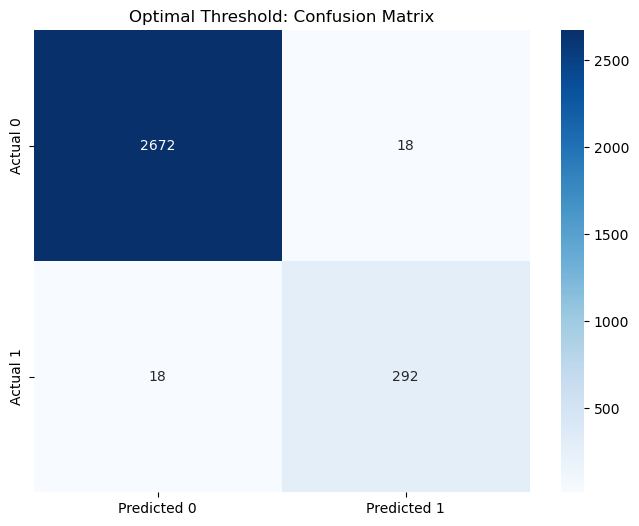

In [62]:
# Plot confusion matrix
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Optimal Threshold: Confusion Matrix')
plt.show()

## Comparison of Techniques

Let's compare all the approaches we've explored:

In [65]:
# Create a comparison table
models = {
    'Baseline': {'predictions': y_pred_baseline, 'probabilities': baseline_model.predict_proba(X_test_scaled)[:, 1]},
    'Random Oversampling': {'predictions': y_pred_ros, 'probabilities': ros_model.predict_proba(X_test_scaled)[:, 1]},
    'SMOTE': {'predictions': y_pred_smote, 'probabilities': smote_model.predict_proba(X_test_scaled)[:, 1]},
    'Random Undersampling': {'predictions': y_pred_rus, 'probabilities': rus_model.predict_proba(X_test_scaled)[:, 1]},
    'SMOTETomek': {'predictions': y_pred_st, 'probabilities': st_model.predict_proba(X_test_scaled)[:, 1]},
    'Class Weights': {'predictions': y_pred_weighted, 'probabilities': weighted_model.predict_proba(X_test_scaled)[:, 1]},
    'Optimal Threshold': {'predictions': y_pred_optimal, 'probabilities': baseline_model.predict_proba(X_test_scaled)[:, 1]}
}

# Compare metrics for minority class
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = []
for name, model_dict in models.items():
    preds = model_dict['predictions']
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

# Create a DataFrame for easy comparison
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

               Model  Accuracy  Precision   Recall  F1 Score
            Baseline  0.988667   0.996403 0.893548  0.942177
 Random Oversampling  0.980667   0.875000 0.948387  0.910217
               SMOTE  0.983000   0.893617 0.948387  0.920188
Random Undersampling  0.980333   0.872404 0.948387  0.908810
          SMOTETomek  0.985333   0.915625 0.945161  0.930159
       Class Weights  0.979000   0.860058 0.951613  0.903522
   Optimal Threshold  0.988000   0.941935 0.941935  0.941935


In [66]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.988667,0.996403,0.893548,0.942177
1,Random Oversampling,0.980667,0.875000,0.948387,0.910217
2,SMOTE,0.983000,0.893617,0.948387,0.920188
3,Random Undersampling,0.980333,0.872404,0.948387,0.908810
4,SMOTETomek,0.985333,0.915625,0.945161,0.930159
5,Class Weights,0.979000,0.860058,0.951613,0.903522
6,Optimal Threshold,0.988000,0.941935,0.941935,0.941935


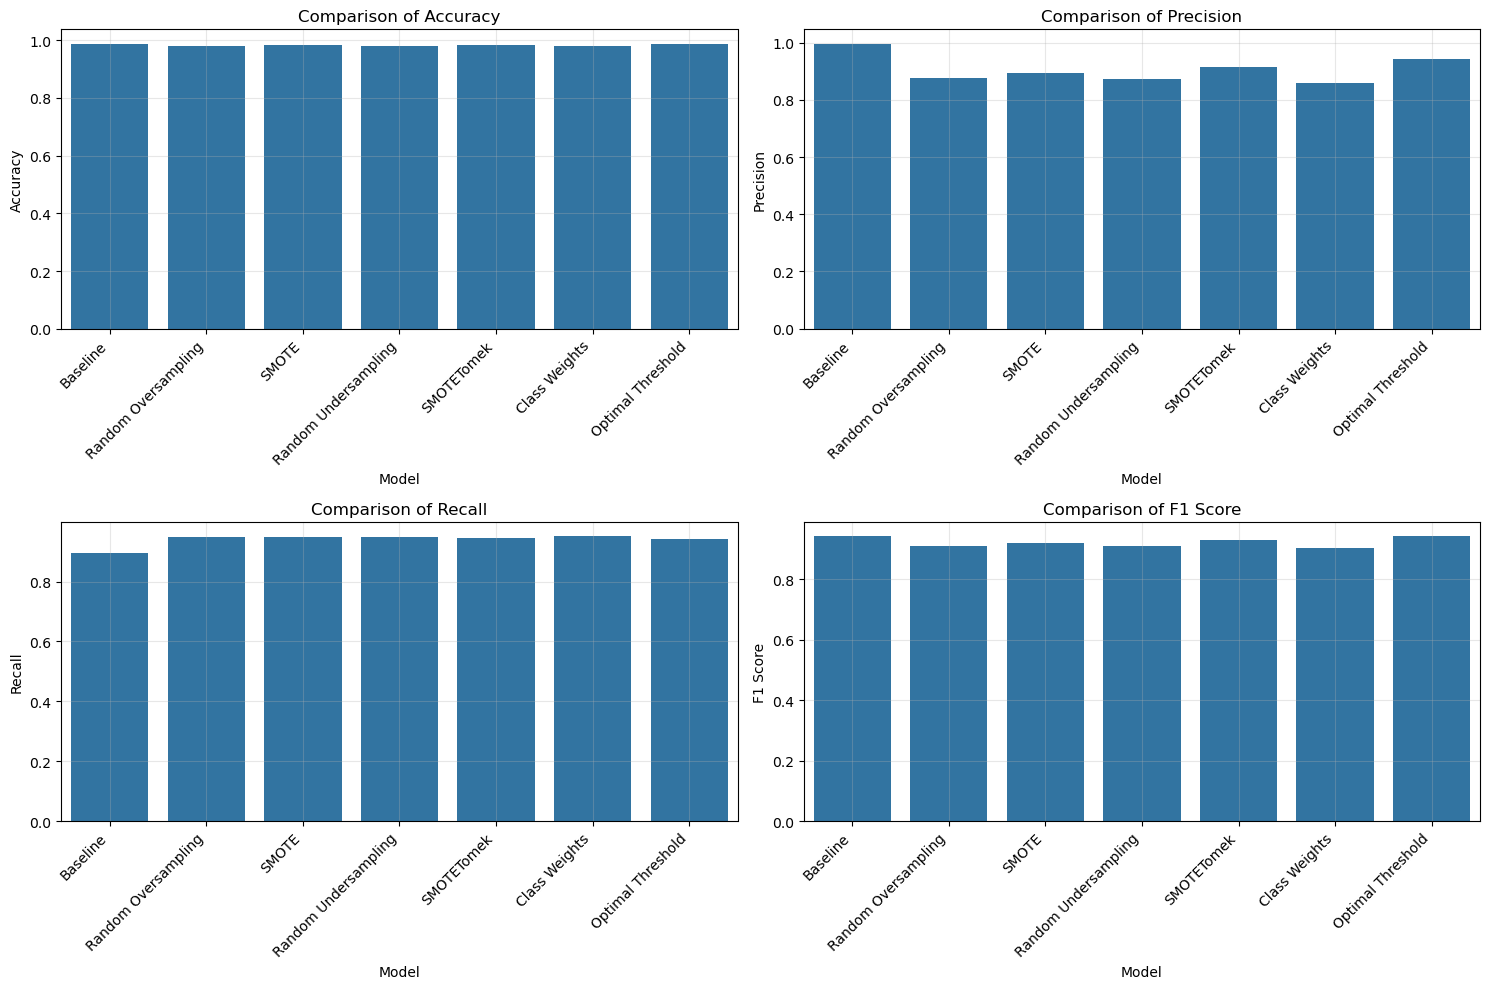

In [68]:
# Visualize the comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()
for i, metric in enumerate(metrics):
    ax = axs[i]
    sns.barplot(x='Model', y=metric, data=results_df, ax=ax)
    ax.set_title(f'Comparison of {metric}')
    
    # Get the current tick positions and labels
    ticks_pos = ax.get_xticks()
    tick_labels = [item.get_text() for item in ax.get_xticklabels()]
    
    # Fix the tick positions and set rotated labels
    ax.set_xticks(ticks_pos)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Let's also create a comprehensive comparison table that highlights the pros and cons of each approach:

In [69]:
# Create a comparison table of technique pros and cons
technique_comparison = pd.DataFrame({
    'Technique': [
        'Random Oversampling', 
        'SMOTE', 
        'Random Undersampling', 
        'Tomek Links', 
        'Combined (SMOTETomek)', 
        'Class Weights', 
        'Threshold Adjustment'
    ],
    'Pros': [
        'Simple to implement, preserves all majority samples',
        'Creates synthetic samples, less overfitting than random oversampling',
        'Simple to implement, reduces training time',
        'Removes noisy samples, improves decision boundary',
        'Balances data while cleaning decision boundary',
        'No data modification needed, works with any classifier that supports weights',
        'Simple, no retraining needed, can optimize for specific metric'
    ],
    'Cons': [
        'Can lead to overfitting, duplicates existing samples',
        'May create noisy samples, not suitable for high-dimensional data',
        'Loss of potentially important information',
        'Minimal effect if classes don\'t overlap much',
        'More complex, may not always improve performance',
        'Requires tuning, not all classifiers support weights',
        'Single threshold may not be optimal for all scenarios'
    ],
    'Best Use Cases': [
        'Small datasets, when preserving all majority data is important',
        'Low to medium dimensional data with reasonable separation',
        'Very large datasets with highly imbalanced classes',
        'Datasets with overlapping classes and noisy points',
        'Complex datasets with both class imbalance and noise',
        'When data modification is not desired, for algorithms supporting weights',
        'When quick adjustment is needed or optimizing for a specific metric'
    ]
})

print(technique_comparison.to_string(index=False))

            Technique                                                                         Pros                                                             Cons                                                           Best Use Cases
  Random Oversampling                          Simple to implement, preserves all majority samples             Can lead to overfitting, duplicates existing samples           Small datasets, when preserving all majority data is important
                SMOTE         Creates synthetic samples, less overfitting than random oversampling May create noisy samples, not suitable for high-dimensional data                Low to medium dimensional data with reasonable separation
 Random Undersampling                                   Simple to implement, reduces training time                        Loss of potentially important information                       Very large datasets with highly imbalanced classes
          Tomek Links                            Rem

## Comparing Algorithm-Level vs. Data-Level Approaches

Contrasting the strengths and weaknesses of both approaches for handling class imbalance.

### When to Choose Algorithm-Level Approaches

- When preserving the original data distribution is important
- When dealing with very large datasets where resampling is inefficient
- When working with streaming or online learning scenarios
- When data generation (like SMOTE) might create unrealistic synthetic examples
- When the imbalance is moderate and can be handled with simple adjustments

### When to Choose Data-Level Approaches

- When the minority class has too few examples for the algorithm to learn patterns
- When the algorithm doesn't support class weighting or cost-sensitive learning
- When the decision boundary needs to be substantially shifted
- When working with algorithms that are sensitive to class proportions
- When synthetic examples can validly represent the minority class

### Combining Both Approaches

Often, the best performance comes from combining data-level and algorithm-level approaches:

- Use mild oversampling to increase minority representation
- Apply class weights to further adjust importance
- Use threshold optimization for the final decision

#### Implementation

In [71]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Create a pipeline that combines both approaches
pipeline = Pipeline([
    # Data-level: Mild SMOTE (not fully balancing)
    ('sampling', SMOTE(sampling_strategy=0.5, random_state=42)),  # Bring minority to 50% of majority
    
    # Algorithm-level: Class-weighted Random Forest
    ('classifier', RandomForestClassifier(
        class_weight='balanced_subsample',  # Algorithm-level adjustment
        random_state=42
    ))
])

# Train the pipeline
pipeline.fit(X_train, y_train)

# Get predicted probabilities
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# Algorithm-level: Threshold optimization
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

# Apply the optimal threshold
y_pred = (y_pred_proba >= optimal_threshold).astype(int)

## Knowledge Check

Let's test your understanding of techniques for handling imbalanced data:

1. **Multiple Choice**: Which resampling technique creates new synthetic samples for the minority class?
   a) Random Oversampling
   b) SMOTE
   c) Random Undersampling
   d) Tomek Links

In [ ]:
python
   # Answer
   print("b) SMOTE (Synthetic Minority Over-sampling Technique)")

2. **True or False**: When using resampling techniques, it's best to apply them to the entire dataset before splitting into training and testing sets.

In [ ]:
python
   # Answer
   print("False. Resampling should only be applied to the training data to avoid data leakage.")

3. **Short Answer**: What is the main advantage of using class weights compared to resampling techniques?

In [ ]:
python
   # Answer
   print("Class weights don't modify the original data, reducing the risk of overfitting and information loss. They also don't increase training time by adding more samples.")

4. **Application**: For a fraud detection system where missing a fraud case (false negative) is 10 times more costly than falsely flagging a legitimate transaction (false positive), how would you set up class weights?

In [ ]:
python
   # Answer
   print("Set class_weight={0: 1, 1: 10}, where 1 is the fraud class. This makes misclassifying a fraud case 10 times more costly than misclassifying a non-fraud case.")

## Summary

In this section, we've explored various techniques for handling imbalanced datasets:

1. **Data-level approaches**:
   - **Oversampling techniques** like Random Oversampling and SMOTE increase the number of minority class samples
   - **Undersampling techniques** like Random Undersampling and Tomek Links reduce the number of majority class samples
   - **Combined approaches** like SMOTETomek use both oversampling and undersampling

2. **Algorithm-level approaches**:
   - **Class weights** penalize misclassification of the minority class more heavily
   - Finding optimal weights through cross-validation can improve performance

3. **Threshold adjustment**:
   - Modifying the classification threshold can optimize specific metrics like precision or recall
   - This is a simple technique that can be applied after model training

Each approach has its own advantages and disadvantages, and the best choice depends on:
- The specific problem domain
- The degree of imbalance
- The size of the dataset
- The computational resources available
- The specific metric you want to optimize

In practice, it's often best to try multiple approaches and compare their performance using appropriate metrics like precision, recall, F1-score, or the area under the precision-recall curve.